# Procesamiento de Imágenes - UNS - Doctorado

## Trabajo Práctico 4 - Transformada de Fourier

1. Armar un aplicativo que permita la generación de transformadas de Fourier (TF) directas e inversas de imágenes.
2. Probarlo con diferentes figuras geométricas y tratar de reproducir algunos de los ejemplos vistos en clase. Generar otros ejemplos (elipses, rombos, dos o más objetos, etc.).
3. Guardar el espectro de amplitud de una imagen en un archivo bitmap; luego editarlo con un editor gráfico y, finalmente, aplicar la transformada inversa (preservando la fase) para analizar los efectos obtenidos.


In [1]:
# load and display an image with Matplotlib
import os
import math
import cmath
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.ticker as ticker

from collections import Counter
from skimage.transform import resize
from PIL import Image

import warnings     # (Opcional) Es para evitar algunos mensajes de warning.
warnings.filterwarnings('ignore')

#Para realizar los graficos en la misma linea de codigo.
%matplotlib inline

#%matplotlib notebook
from matplotlib.widgets import Slider

In [2]:
def read_img(path):

    name = os.path.basename(path)

    rename, ext = os.path.splitext(name)

    img = mpimg.imread(path)

    if img.shape[1] > 1024:        
    
        h, w = img.shape[:2]
        new_width = 1024
        ratio = new_width / w
        new_height = int(h * ratio)

        image_resized = resize(
            img,
            (new_height, new_width),
            preserve_range=True,
            anti_aliasing=True
        ).astype(img.dtype)

        mpimg.imsave(
            os.path.join(os.getcwd(), "data", f"{rename}_resized{ext}"),
            image_resized
        )

        img = mpimg.imread(os.path.join(os.getcwd(), "data", f"{rename}_resized{ext}"))        

    return img

In [3]:
class Imagen:

    def __init__(self, img_size):

        self.img_size = img_size
        
        self.height = self.img_size
        self.width = self.img_size
        self.bg_value = 255
        
        self.y, self.x = np.ogrid[:self.height, :self.width]

        self.cx = self.width // 2
        self.cy = self.height // 2

    def generate_image(self):
        
        return np.full(
            (self.height, self.width),
            self.bg_value,
            dtype=np.uint8
        )     

In [4]:
class Circle(Imagen):
    
    def __init__(self, img_size, radius):

        super().__init__(img_size)
        
        self.radius = radius if radius <= img_size // 2 else img_size // 2

    def draw(self):

        img = self.generate_image()

        mask = (self.x - self.cx)**2 + (self.y - self.cy)**2 <= self.radius**2

        img[mask] = 0

        plt.imshow(img, cmap="gray")
        plt.axis('off')
        plt.show()
        
        return img     

In [5]:
class Square(Imagen):
    
    def __init__(self, img_size, side):
        
        super().__init__(img_size)
        
        self.side = side

    def draw(self):

        img = self.generate_image()

        mask = (
            (self.x >= self.cx - self.side / 2) & (self.x <= self.cx + self.side / 2) &
            (self.y >= self.cy - self.side / 2) & (self.y <= self.cy + self.side / 2)
        )

        img[mask] = 0

        plt.imshow(img, cmap="gray")
        plt.axis('off')
        plt.show()
        
        return img 

In [6]:
class Rectangle(Imagen):
    
    def __init__(self, img_size, lx, ly):
        
        super().__init__(img_size)
        
        self.lx = lx

        self.ly = ly

        self.type = type

    def draw(self):

        img = self.generate_image()     

        mask = (
            (self.x >= self.cx - self.lx / 2) & (self.x <= self.cx + self.lx / 2) &
            (self.y >= self.cy - self.ly / 2) & (self.y <= self.cy + self.ly / 2)
        )
      
        img[mask] = 0

        plt.imshow(img, cmap="gray")
        plt.axis('off')
        plt.show()
        
        return img

In [7]:
class Rhombus(Imagen):

    def __init__(self, img_size, dx, dy):
        
        super().__init__(img_size)
        
        self.dx = dx if dx <= img_size / 2 else img_size / 2

        self.dy = dy if dy <= img_size / 2 else img_size / 2

        self.side = math.sqrt(self.dx ** 2 + self.dy ** 2)

        self.type = type

    def draw(self):

        img = self.generate_image()      

        mask = (np.abs(self.x - self.cx) / self.dx) + (np.abs(self.y - self.cy) / self.dy) <= 1                

        img[mask] = 0

        plt.imshow(img, cmap="gray")
        plt.axis('off')
        plt.show()
        
        return img   

In [8]:
class Ellipse(Imagen):
    
    def __init__(self, img_size, a, b):
        
        super().__init__(img_size)
        
        self.a = a if a <= img_size / 2 else img_size / 2

        self.b = b if b <= img_size / 2 else img_size / 2

    def draw(self):

        img = self.generate_image()

        mask = ((self.x - self.cx)**2 / (self.a**2)) + ((self.y - self.cy)**2 / (self.b**2)) <= 1

        img[mask] = 0

        plt.imshow(img, cmap="gray")
        plt.axis('off')
        plt.show()
        
        return img 

In [9]:
class WorkFlowFourier:

    def __init__(self, img, type_img="figure", output="save.jpg"):
        
        self.output = output

        img = np.asarray(img)

        if type_img == "figure":
            
            self.img = img.astype(np.float32) / 255.0

        elif type_img == "upload_image":
            
            if img.dtype == np.uint8:
                
                self.img = img.astype(np.float32) / 255.0
            else:
                self.img = img.astype(np.float32)

        else:
            
            raise ValueError("type_img debe ser 'figure' o 'upload_image'")

        if self.img.ndim == 2:
            
            self.img = np.stack([self.img, self.img, self.img], axis=-1)
            
        if self.img.shape[-1] == 4:
            
            self.img = self.img[..., :3]

        self.img = np.clip(self.img, 0.0, 1.0)

        # Variables caché
        self._dict_YIQ_meta = None
        self._fft_meta = None
        self._Y_mean = 0.0
        self._F = None

    def rgb_to_yiq(self):

        rgb = self.img.astype(np.float32)

        #modified_img = np.copy(self.img)            

        # height, width, channels = modified_img.shape

        # for i in range(height):
    
        #     for j in range(width):

        #         r, g, b = modified_img[i, j]

        #         change_y = 0.299 * r + 0.587 * g + 0.114 * b
        #         change_i = 0.595716 * r - 0.274453 * g - 0.321263 * b
        #         change_q = 0.211456 * r - 0.522591 * g + 0.311135 * b

        #         modified_img[i, j] = [change_y, change_i + 0.5, change_q + 0.5]

        r = rgb[:, :, 0].astype(np.float32)
        g = rgb[:, :, 1].astype(np.float32)
        b = rgb[:, :, 2].astype(np.float32)

        Y = 0.299 * r + 0.587 * g + 0.114 * b
        I = 0.595716 * r - 0.274453 * g - 0.321263 * b
        Q = 0.211456 * r - 0.522591 * g + 0.311135 * b

        I_off = I + 0.5
        Q_off = Q + 0.5

        yiq = np.stack([Y, I_off, Q_off], axis=-1)


        self._dict_YIQ_meta = {
            "I": I_off.astype(np.float32),
            "Q": Q_off.astype(np.float32)
        }
        
        return yiq

    def yiq_to_rgb(self):

        Y = self.ifft_y()

        if self._dict_YIQ_meta is None:
            
            raise RuntimeError("Primero ejecutá fft_y() o rgb_to_yiq() para cachear I/Q.")

        I = self._dict_YIQ_meta["I"] - 0.5
        Q = self._dict_YIQ_meta["Q"] - 0.5

        # height, width = self._fft_meta["shape"][0], self._fft_meta["shape"][1]

        # yiq = np.stack((Y, I, Q), axis=2)

        # for a in range(height):
    
        #     for b in range(width):
                
        #         y, i, q = yiq[a, b]
        
        #         i -= 0.5
        #         q -= 0.5
        
        #         change_r = y + 0.9663 * i + 0.6210 * q
        
        #         change_g = y - 0.2721 * i - 0.6474 * q
        
        #         change_b = y - 1.1070 * i + 1.7046 * q        
                
        #         yiq[a, b] = [change_r, change_g, change_b]
                
        # return np.clip(yiq, 0.0, 1.0)

        R = Y + 0.9663 * I + 0.6210 * Q
        G = Y - 0.2721 * I - 0.6474 * Q
        B = Y - 1.1070 * I + 1.7046 * Q
    
        rgb = np.stack((R, G, B), axis=2)
    
        return np.clip(rgb, 0.0, 1.0)
    
    @staticmethod    
    def _fftshift2d(F: np.ndarray) -> np.ndarray:
        
        return np.fft.fftshift(F)

    @staticmethod    
    def _ifftshift2d(Fuv: np.ndarray) -> np.ndarray:
        
        return np.fft.ifftshift(Fuv)
        
    def fft_y(self, center: str = "mean", shift: bool = True, norm: str = "forward"):

        yiq = self.rgb_to_yiq()

        Y = yiq[:, :, 0].astype(np.float32)      

        height, width = Y.shape

        self._fft_meta = {
            "shape": (height, width), 
            "center": center, 
            "shift": shift,
            "norm": norm,
        }

        if center == "mean":
            self._Y_mean = float(Y.mean())
            Yc = Y - self._Y_mean
        elif center == "none":
            self._Y_mean = 0.0
            Yc = Y
        else:
            raise ValueError("center debe ser 'mean' o 'none'")
        
        # F = np.zeros((height, width), dtype=np.complex128)

        # two_pi = 2.0 * math.pi

        # for u in range(height):

        #     for v in range(width):

        #         suma = 0.0 + 0.0j 
        
        #         for i in range(height):

        #             ux = (u * i) / height
            
        #             for j in range(width):
        
        #                 theta = ux + (v * j) / width
        
        #                 suma += Yc[i][j] * cmath.exp((-1j) * two_pi * theta)   
                        
        #         F[u, v] = suma

        if norm == "forward":
            F = np.fft.fft2(Yc, norm="forward")
        elif norm == "numpy":
            F = np.fft.fft2(Yc)  # default ("backward")
        else:
            raise ValueError("norm debe ser 'numpy' o 'forward'")

        if shift:
            
            F = self._fftshift2d(F)

        self._F = F
        
        return F

    def ifft_y(self):

        if not hasattr(self, "_F") or self._F is None:
            
            raise RuntimeError("Primero ejecutá fft_y() antes de ifft_y().")

        Fuv = self._F
        metadata = self._fft_meta
        height, width = metadata["shape"]

        if metadata["shift"]:
            
            Fuv = np.fft.ifftshift(Fuv)

        # Yc_rec = np.zeros((height, width), dtype=np.complex128)

        # two_pi = 2.0 * math.pi

        # for i in range(height):

        #     for j in range(width):

        #         suma = 0.0 + 0.0j 
        
        #         for u in range(height):

        #             ix = (i * u) / height
            
        #             for v in range(width):
        
        #                 theta = ix + (j * v) / width
        
        #                 suma += Fuv[u][v] * cmath.exp((1j) * two_pi * theta)   
                        
        #         Yc_rec[i, j] = suma        


        # if metadata["center"] == "mean":

        #     Y = Yc_rec + self._Y_mean
        
        # elif metadata["center"] == "none":
        
        #     Y = Yc_rec
        
        # else:
            
        #     raise ValueError("center debe ser 'mean' o 'none'")

        # if metadata["norm"] == "forward":
            
        #     pass
            
        # elif metadata["norm"] == "numpy":
            
        #     Y = Y / (height * width)
            
        # else:
            
        #     raise ValueError("norm debe ser 'numpy' o 'forward'")

        if metadata["norm"] == "forward":
            
            Yc_rec = np.fft.ifft2(Fuv, norm="forward")
            
        elif metadata["norm"] == "numpy":
            
            Yc_rec = np.fft.ifft2(Fuv)  # default ("backward")
        
        else:
            
            raise ValueError("norm debe ser 'numpy' o 'forward'")

        
        if metadata["center"] == "mean":
            
            Y = Yc_rec + self._Y_mean
            
        elif metadata["center"] == "none":
            
            Y = Yc_rec
            
        else:
            
            raise ValueError("center debe ser 'mean' o 'none'")

        return np.real(Y)

    # Visualización / IO 
    def show_fft_and_rec(
        self,
        center="none",
        shift=True,
        log_scale=True,
        normalize=True,
        norm="numpy",
        fft_filename="fft.png",
        rec_filename="reconstruida.png",
    ):
        """
        Muestra FFT (magnitud) y reconstrucción lado a lado
        y guarda ambas imágenes.
        """

        # 1) FFT (una sola vez)
        F = self.fft_y(center=center, shift=shift, norm=norm)
    
        mag = np.abs(F)
    
        if log_scale:
            mag = np.log1p(mag)
    
        if normalize:
            mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
    
      
        rec = self.yiq_to_rgb()
    
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
        axes[0].imshow(mag, cmap="gray")
        axes[0].set_title("FFT | Magnitud")
        axes[0].axis("off")
    
        axes[1].imshow(rec)
        axes[1].set_title("Imagen reconstruida (YIQ → RGB)")
        axes[1].axis("off")
    
        plt.tight_layout()
        plt.show()
    
        # 4) Guardado
        out_dir = os.path.join(os.getcwd(), "new")
        os.makedirs(out_dir, exist_ok=True)
    
        fft_out = (mag * 255.0 + 0.5).astype(np.uint8)
        mpimg.imsave(os.path.join(out_dir, fft_filename), fft_out, cmap="gray")
    
        mpimg.imsave(os.path.join(out_dir, rec_filename), rec)

    # Wrappers de compatibilidad
    def show_fft(self, **kwargs):
        self.show_fft_and_rec(**kwargs)    
    
    def image_rec(self):
        self.show_fft_and_rec()    

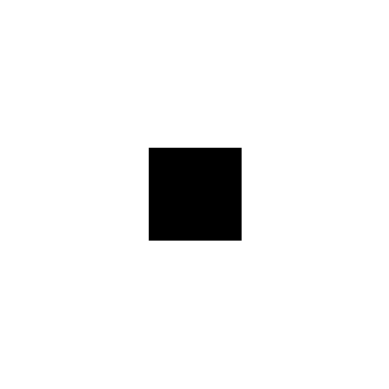

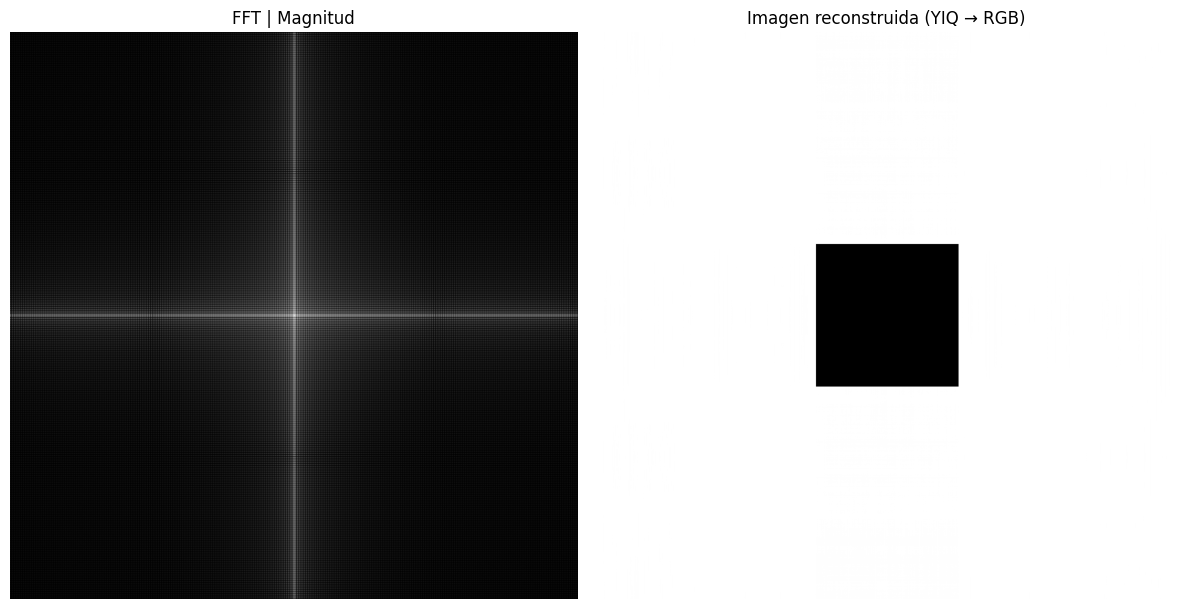

In [10]:
cuadrado = Square(1024, 256).draw()
w_fourier = WorkFlowFourier(cuadrado, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_square.png")

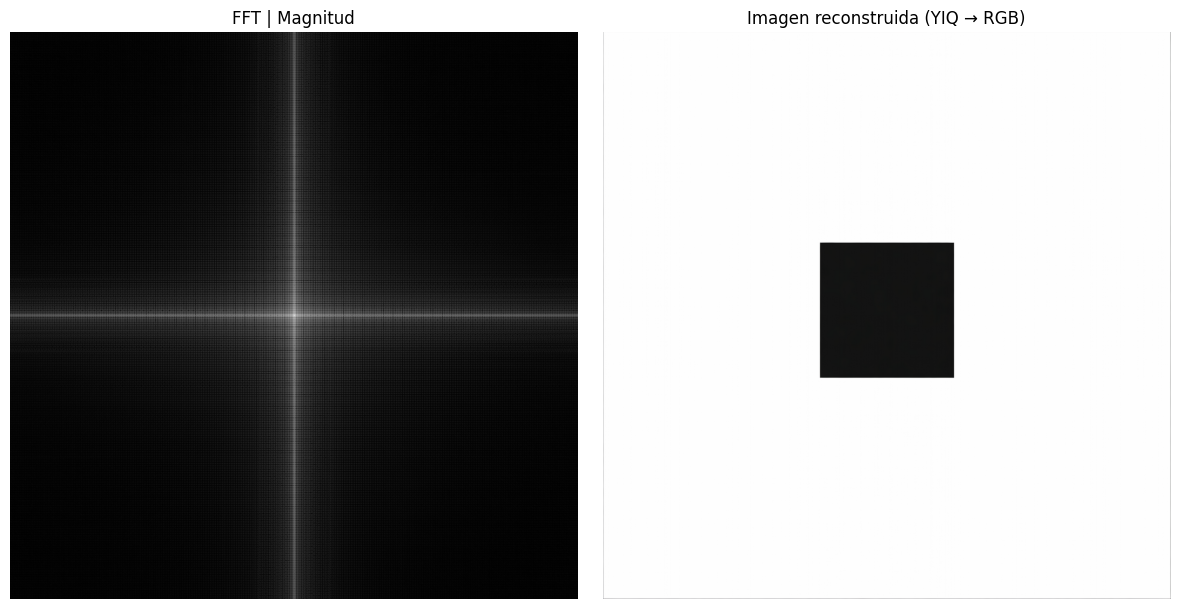

In [11]:
square_image = read_img(os.path.join("data", "square_image.png"))
shelly_fft = WorkFlowFourier(square_image, "upload_image", "numpy_im_square.png")
shelly_fft.show_fft_and_rec(fft_filename="numpy_img_square.png")

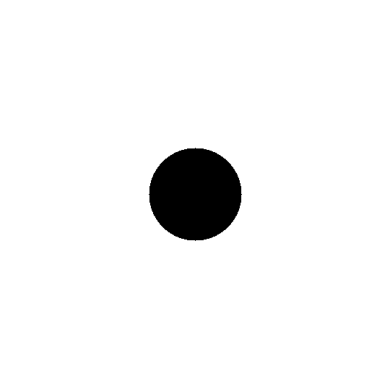

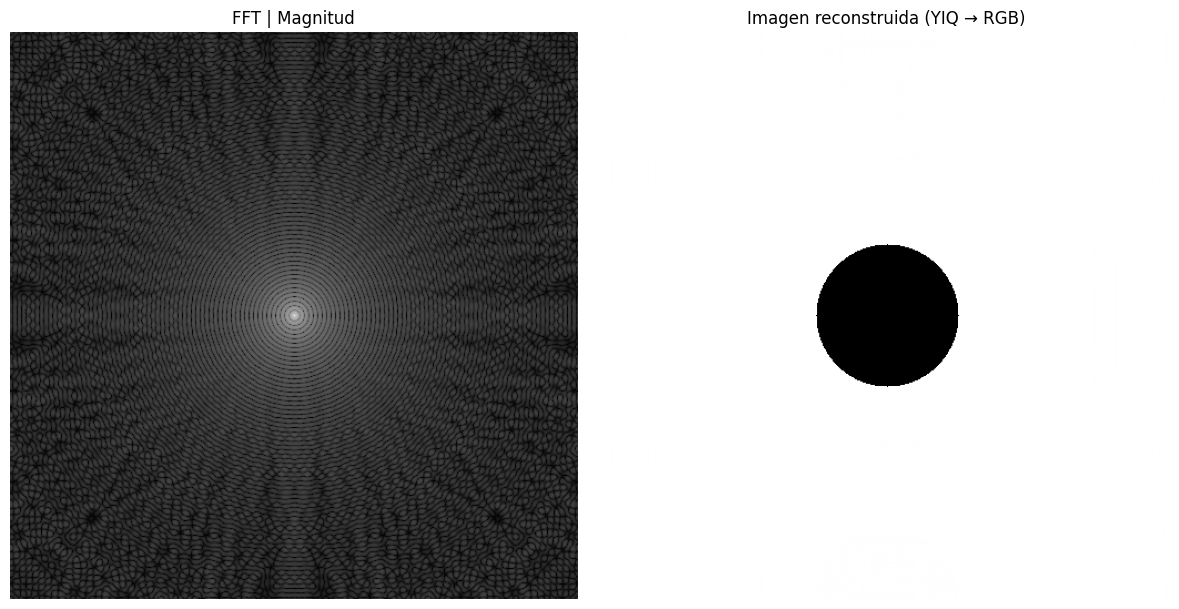

In [12]:
circulo = Circle(512, 64).draw()
w_fourier = WorkFlowFourier(circulo, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_circle.png")

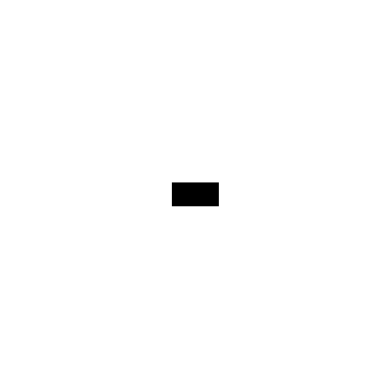

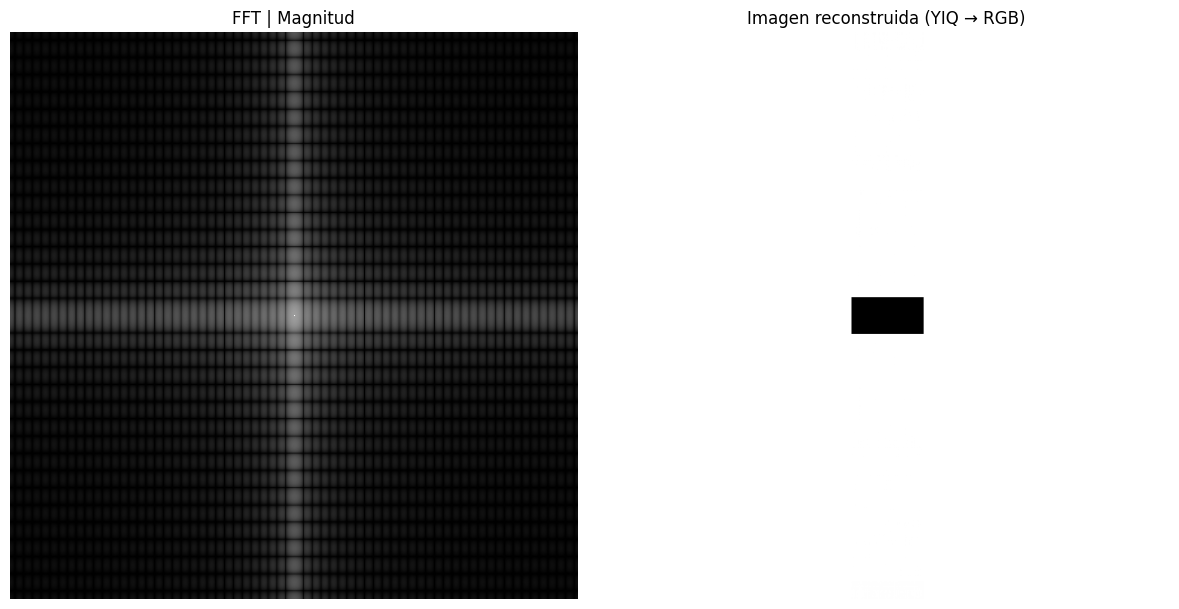

In [13]:
rectangulo = Rectangle(512, 64, 32).draw()
w_fourier = WorkFlowFourier(rectangulo, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_rectangle.png")

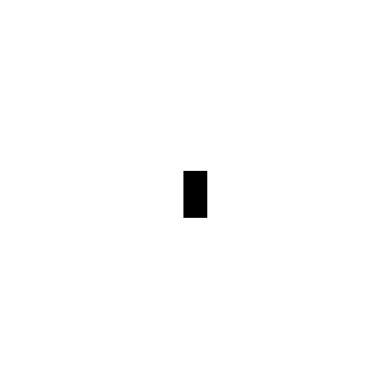

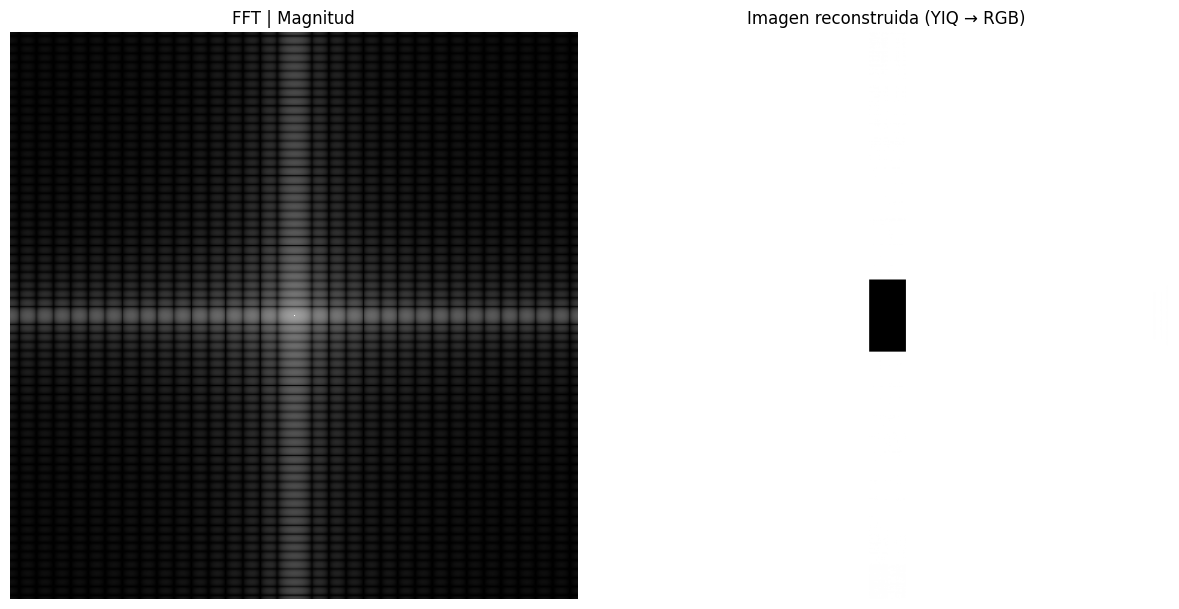

In [14]:
rectangulo = Rectangle(512, 32, 64).draw()
w_fourier = WorkFlowFourier(rectangulo, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_rectangle_v.png")

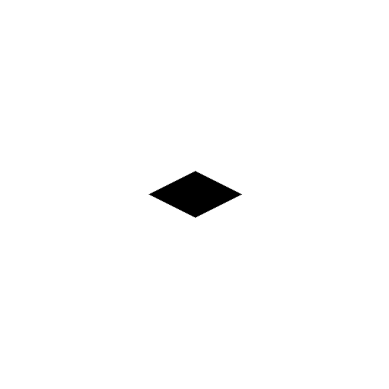

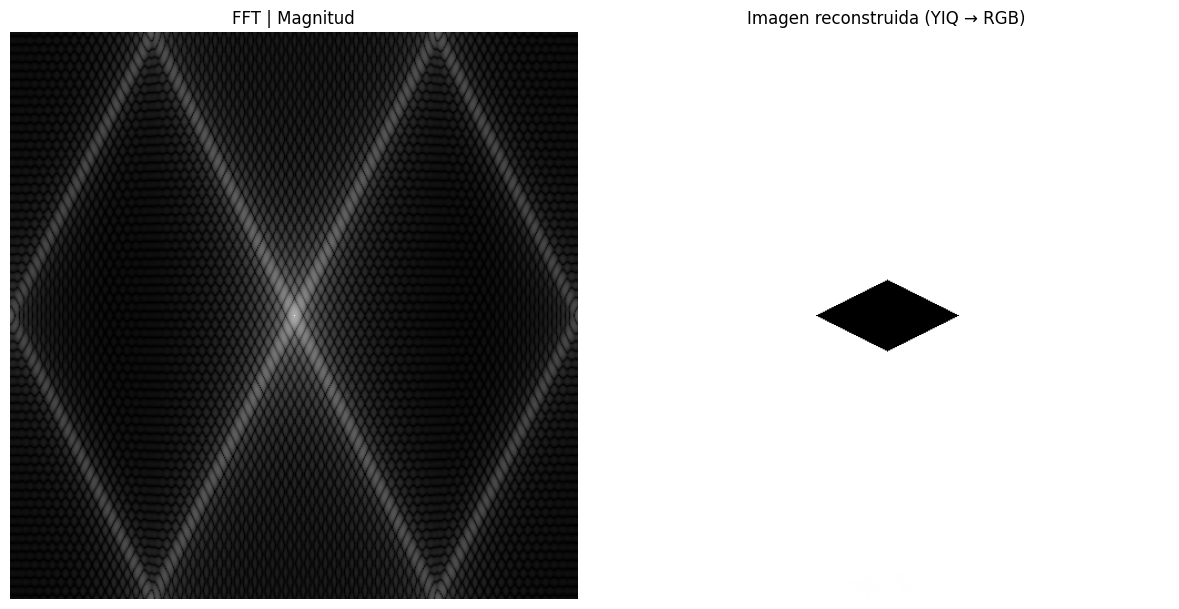

In [15]:
rombo = Rhombus(512, 64, 32).draw()
w_fourier = WorkFlowFourier(rombo, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_rombov.png")

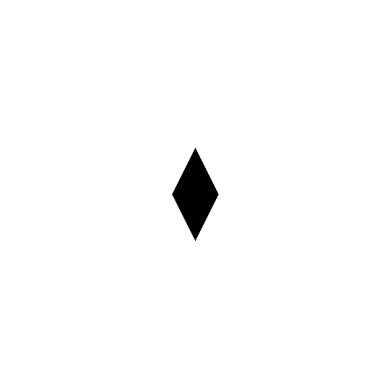

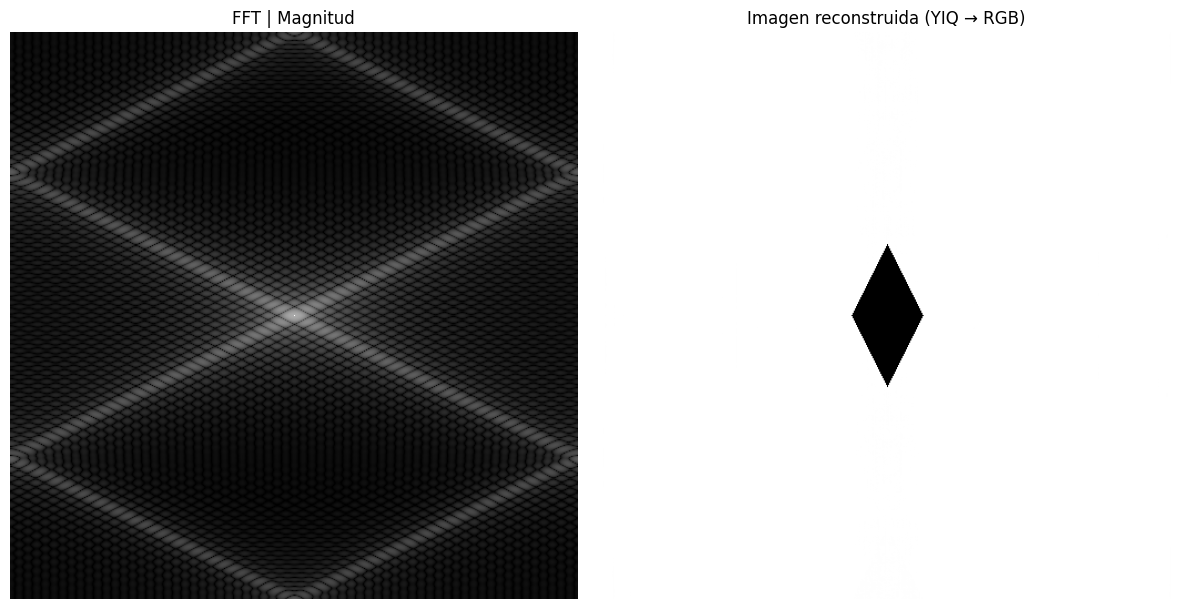

In [16]:
rombo = Rhombus(512, 32, 64).draw()
w_fourier = WorkFlowFourier(rombo, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_romboh.png")

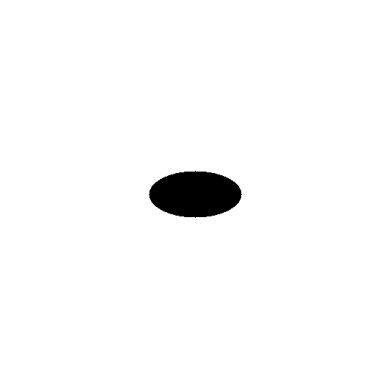

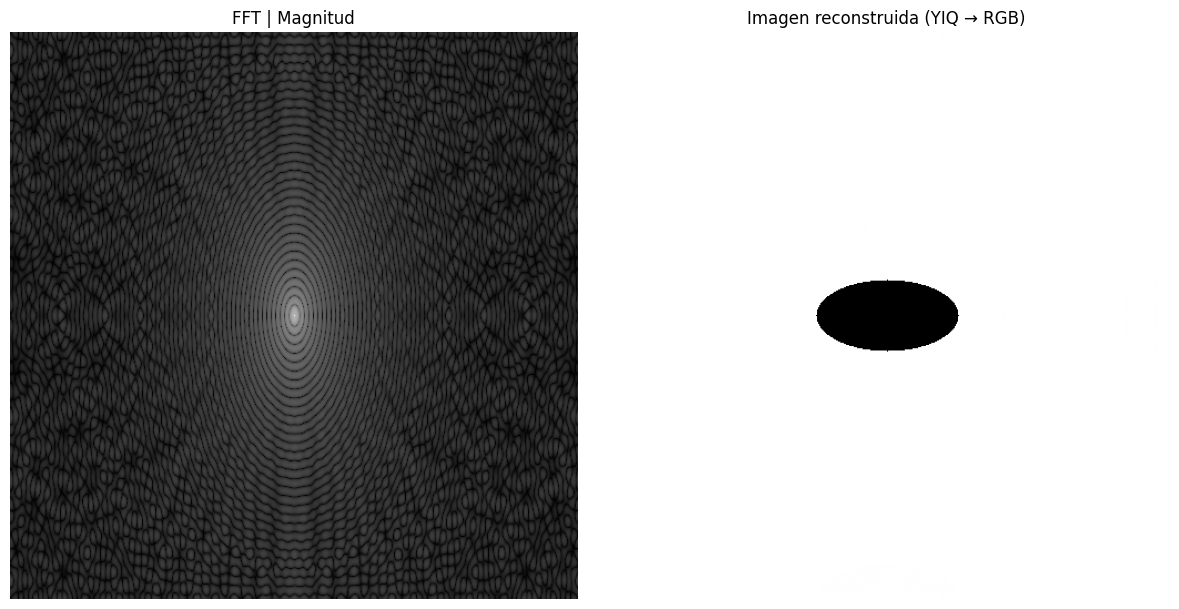

In [17]:
elipse = Ellipse(512, 64, 32).draw()
w_fourier = WorkFlowFourier(elipse, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_elipse.png")

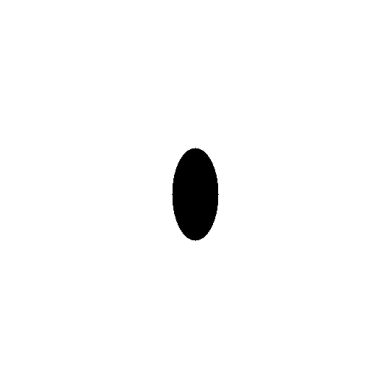

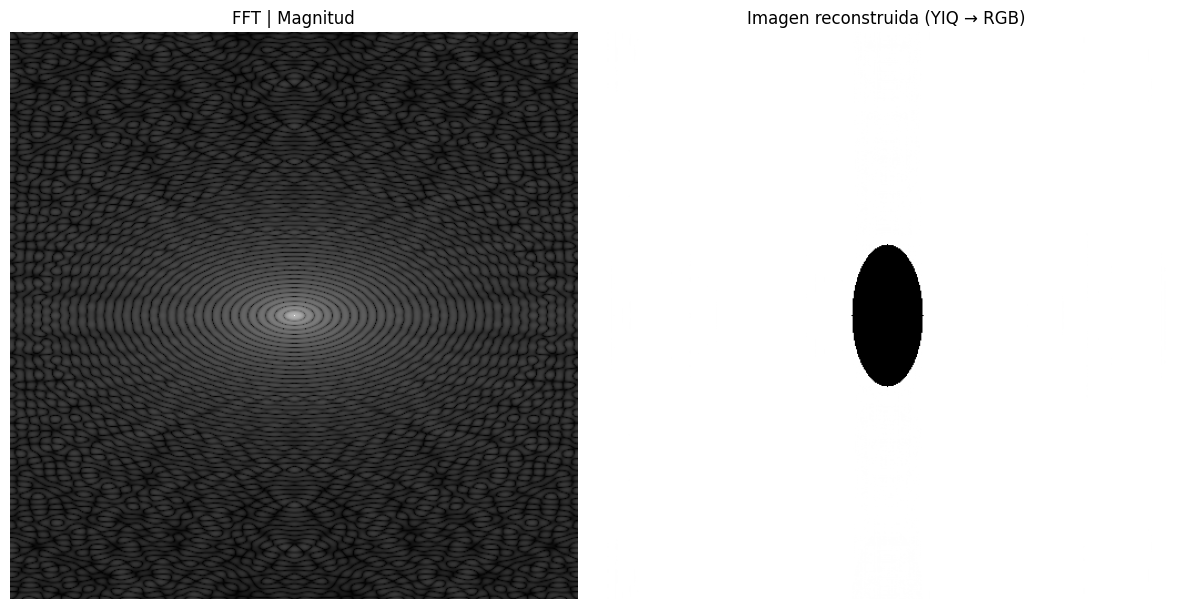

In [18]:
elipse = Ellipse(512, 32, 64).draw()
w_fourier = WorkFlowFourier(elipse, "figure")
w_fourier.show_fft_and_rec(fft_filename="numpy_figure_elipseh.png")

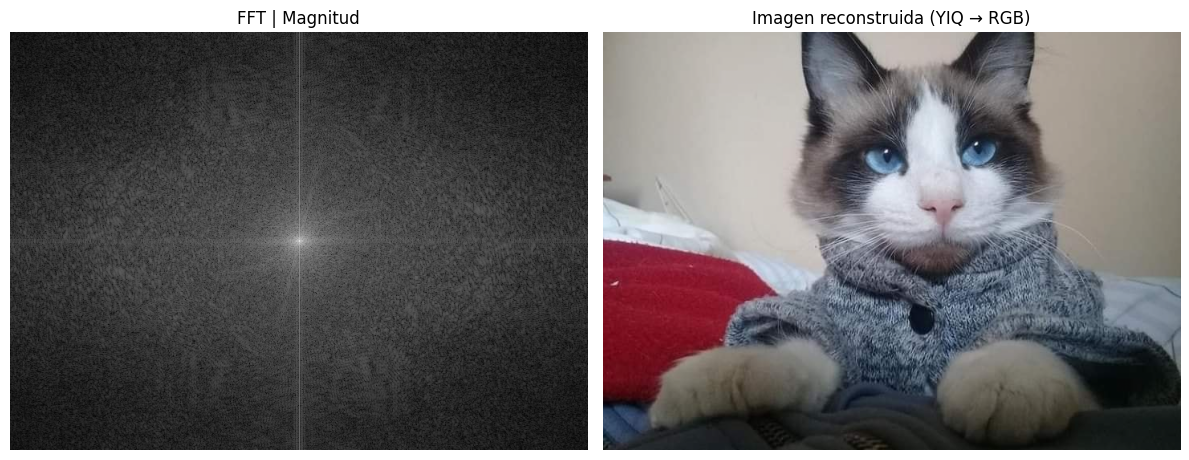

In [20]:
shelly_image = read_img(os.path.join("data", "shelly.jpg"))
shelly_fft = WorkFlowFourier(shelly_image, "upload_image", "numpy_im_shelly.png")
shelly_fft.show_fft_and_rec(fft_filename="numpy_img_shelly.png")